# 🛒 Pandas Assignment — E-Commerce Sales Analysis
### Olist Brazilian E-Commerce Dataset

Welcome to the practical assignment for the Pandas Complete Guide. You will perform a full end-to-end analysis of a real e-commerce company's sales data, applying every pandas technique covered in the lesson notebook.

---

## 🎯 Learning Objectives
By the end of this assignment you will have:
- **Loaded and merged** 7+ related CSV tables (orders, customers, products, sellers, payments, items, reviews)
- **Handled missing values** with multiple strategies based on context
- **Joined and merged** DataFrames using every join type (inner, left, right, outer)
- **Performed group-by aggregations** for business KPIs
- **Conducted time-series analysis** including resampling, rolling windows, and trend detection
- **Produced a final business report** with concrete, data-backed insights

---

## 📦 The Dataset

We use the **Olist Brazilian E-Commerce Public Dataset** — 100,000+ real (anonymized) orders from 2016–2018, organized across 9 interrelated tables. This is one of the most popular publicly available sales datasets and is widely used in data science portfolios.

### Schema overview
```
                  ┌─────────────┐
                  │  customers  │
                  └──────┬──────┘
                         │ customer_id
                  ┌──────▼──────┐
        ┌────────►│   orders    │◄────────┐
        │         └──────┬──────┘         │
        │ order_id       │ order_id       │ order_id
┌───────┴──────┐  ┌──────▼─────┐   ┌──────┴────────┐
│   reviews    │  │ order_items │   │   payments   │
└──────────────┘  └─┬─────────┬─┘   └──────────────┘
                    │         │
              product_id   seller_id
                    │         │
              ┌─────▼───┐ ┌───▼────┐
              │ products│ │ sellers│
              └─────────┘ └────────┘
```

### 📥 How to obtain the dataset

**Option A — Real Olist data (recommended for portfolio work):**
1. Visit https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
2. Sign in to Kaggle (free) and click **Download** to get `archive.zip` (~45 MB)
3. Extract and place all CSV files into a folder named `olist_data/` in the same directory as this notebook
4. Set `USE_REAL_DATA = True` in the setup cell below

**Option B — Synthetic equivalent (run immediately):**
- Leave `USE_REAL_DATA = False` (default)
- The notebook will generate a smaller synthetic dataset with the same schema and column names
- All assignment questions and code work identically on both datasets

> **Tip:** start with Option B to build your code. If you want to extend the work into a portfolio piece, swap to Option A — your code will keep working on the larger real dataset.

---

## 📝 How to Submit

Fill in every code cell marked `# Your code here`. Add markdown cells with your interpretation wherever a question asks **"explain"** or **"comment"**.

Each section has its own **rubric** at the top — check yourself before moving on.

> ⏱ **Estimated time:** 6–10 hours of focused work depending on depth of exploration.

---
## 🔧 Setup

Run these cells first. They import libraries and either load the real Olist files or generate synthetic equivalents.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

# ────────────────────────────────────────────────────────────────────
# SWITCH BETWEEN REAL OLIST DATA AND SYNTHETIC DATA
# ────────────────────────────────────────────────────────────────────
USE_REAL_DATA = True   # set to True if you've downloaded Olist from Kaggle
DATA_DIR = 'dataset/'  # folder containing the Olist CSVs (real data only)

print(f"USE_REAL_DATA = {USE_REAL_DATA}")
print(f"pandas = {pd.__version__}")

USE_REAL_DATA = True
pandas = 3.0.3


### Synthetic data generator (only runs if `USE_REAL_DATA = False`)

This builds 7 CSV files with the same column names as the real Olist dataset. Records are interrelated and span 2 years so the time-series questions are meaningful.

In [2]:
import os

if not USE_REAL_DATA:
    rng = np.random.default_rng(42)
    os.makedirs('synthetic_olist', exist_ok=True)

    # ── 1. CUSTOMERS ────────────────────────────────────────────────
    n_customers = 3000
    states = ['SP','RJ','MG','RS','PR','SC','BA','DF','GO','PE','CE','PA','MA','MT','MS']
    state_p = [0.42,0.13,0.12,0.06,0.05,0.04,0.04,0.03,0.03,0.02,0.02,0.01,0.01,0.01,0.01]
    cities = {
        'SP':['sao paulo','campinas','santos','ribeirao preto','sorocaba'],
        'RJ':['rio de janeiro','niteroi','duque de caxias'],
        'MG':['belo horizonte','uberlandia','contagem','juiz de fora'],
        'RS':['porto alegre','caxias do sul','pelotas'],
        'PR':['curitiba','londrina','maringa'],
        'SC':['florianopolis','joinville','blumenau'],
        'BA':['salvador','feira de santana'],
        'DF':['brasilia'],
        'GO':['goiania','aparecida de goiania'],
        'PE':['recife','olinda'],
        'CE':['fortaleza','caucaia'],
        'PA':['belem','ananindeua'],
        'MA':['sao luis'],
        'MT':['cuiaba','varzea grande'],
        'MS':['campo grande'],
    }
    cust_states = rng.choice(states, n_customers, p=state_p)
    customers = pd.DataFrame({
        'customer_id': [f'cust_{i:06d}' for i in range(n_customers)],
        'customer_unique_id': [f'uniq_{rng.integers(0, n_customers*0.85):06d}' for _ in range(n_customers)],
        'customer_zip_code_prefix': rng.integers(1000, 99999, n_customers),
        'customer_city': [rng.choice(cities[s]) for s in cust_states],
        'customer_state': cust_states,
    })
    customers.to_csv('synthetic_olist/olist_customers_dataset.csv', index=False)

    # ── 2. SELLERS ──────────────────────────────────────────────────
    n_sellers = 250
    sel_states = rng.choice(states, n_sellers, p=state_p)
    sellers = pd.DataFrame({
        'seller_id': [f'sell_{i:04d}' for i in range(n_sellers)],
        'seller_zip_code_prefix': rng.integers(1000, 99999, n_sellers),
        'seller_city': [rng.choice(cities[s]) for s in sel_states],
        'seller_state': sel_states,
    })
    sellers.to_csv('synthetic_olist/olist_sellers_dataset.csv', index=False)

    # ── 3. PRODUCTS ────────────────────────────────────────────────
    n_products = 800
    categories = ['cama_mesa_banho','beleza_saude','esporte_lazer','informatica_acessorios',
                  'moveis_decoracao','utilidades_domesticas','relogios_presentes','telefonia',
                  'automotivo','brinquedos','cool_stuff','ferramentas_jardim','perfumaria',
                  'bebes','eletronicos','livros_interesse_geral']
    products = pd.DataFrame({
        'product_id': [f'prod_{i:05d}' for i in range(n_products)],
        'product_category_name': rng.choice(categories, n_products),
        'product_name_lenght': rng.integers(20, 80, n_products).astype(float),
        'product_description_lenght': rng.integers(100, 4000, n_products).astype(float),
        'product_photos_qty': rng.integers(1, 8, n_products).astype(float),
        'product_weight_g': rng.integers(50, 30000, n_products).astype(float),
        'product_length_cm': rng.integers(10, 100, n_products).astype(float),
        'product_height_cm': rng.integers(2, 80, n_products).astype(float),
        'product_width_cm': rng.integers(5, 80, n_products).astype(float),
    })
    # Inject realistic missingness
    for col in ['product_category_name','product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
        miss_idx = rng.choice(n_products, size=int(n_products*0.03), replace=False)
        products.loc[miss_idx, col] = np.nan
    products.to_csv('synthetic_olist/olist_products_dataset.csv', index=False)

    # ── 4. ORDERS ────────────────────────────────────────────────
    n_orders = 7000
    # Build datetime distribution: increasing volume over time + weekly seasonality
    start = pd.Timestamp('2017-01-01')
    days_range = 730
    # weight days so volume grows over time and dips on weekends slightly
    day_weights = []
    for d in range(days_range):
        date = start + pd.Timedelta(days=d)
        base = 0.5 + d/days_range  # linear growth
        if date.weekday() in [5, 6]:
            base *= 0.85  # slightly lower weekend volume
        # holiday spike around November (Black Friday)
        if date.month == 11 and 20 <= date.day <= 28:
            base *= 2.5
        day_weights.append(base)
    day_weights = np.array(day_weights) / sum(day_weights)
    chosen_days = rng.choice(days_range, n_orders, p=day_weights)
    purchase_ts = [start + pd.Timedelta(days=int(d), hours=int(rng.integers(8,23)),
                                         minutes=int(rng.integers(0,60))) for d in chosen_days]
    purchase_ts = pd.to_datetime(purchase_ts)

    statuses = rng.choice(['delivered','shipped','canceled','invoiced','processing'],
                           n_orders, p=[0.92, 0.03, 0.03, 0.01, 0.01])
    approved_ts = [t + pd.Timedelta(hours=int(rng.integers(0,48))) for t in purchase_ts]
    carrier_ts = [t + pd.Timedelta(days=int(rng.integers(1,7))) for t in approved_ts]
    delivered_ts = [t + pd.Timedelta(days=int(rng.integers(2,15))) for t in carrier_ts]
    estimated_ts = [t + pd.Timedelta(days=int(rng.integers(10,25))) for t in purchase_ts]

    orders = pd.DataFrame({
        'order_id': [f'ord_{i:06d}' for i in range(n_orders)],
        'customer_id': rng.choice(customers['customer_id'], n_orders),
        'order_status': statuses,
        'order_purchase_timestamp': purchase_ts,
        'order_approved_at': approved_ts,
        'order_delivered_carrier_date': carrier_ts,
        'order_delivered_customer_date': delivered_ts,
        'order_estimated_delivery_date': estimated_ts,
    })
    # Inject missingness: non-delivered orders have missing delivery dates
    orders.loc[orders['order_status'] != 'delivered', 'order_delivered_customer_date'] = pd.NaT
    orders.loc[orders['order_status'].isin(['canceled','processing','invoiced']),
               'order_delivered_carrier_date'] = pd.NaT
    # A few approved_at missing too
    miss_idx = rng.choice(n_orders, size=int(n_orders*0.005), replace=False)
    orders.loc[miss_idx, 'order_approved_at'] = pd.NaT
    orders.to_csv('synthetic_olist/olist_orders_dataset.csv', index=False)

    # ── 5. ORDER ITEMS ────────────────────────────────────────────────
    item_rows = []
    for i, oid in enumerate(orders['order_id']):
        n_items = rng.choice([1, 1, 1, 1, 2, 2, 3], p=[0.55,0.15,0.05,0.05,0.12,0.05,0.03])
        purchase_t = orders.iloc[i]['order_purchase_timestamp']
        for item_n in range(1, n_items + 1):
            price = round(float(rng.lognormal(4.3, 0.7)), 2)
            freight = round(price * float(rng.uniform(0.05, 0.25)), 2)
            item_rows.append({
                'order_id': oid,
                'order_item_id': item_n,
                'product_id': rng.choice(products['product_id']),
                'seller_id': rng.choice(sellers['seller_id']),
                'shipping_limit_date': purchase_t + pd.Timedelta(days=int(rng.integers(2, 8))),
                'price': price,
                'freight_value': freight,
            })
    order_items = pd.DataFrame(item_rows)
    order_items.to_csv('synthetic_olist/olist_order_items_dataset.csv', index=False)

    # ── 6. PAYMENTS ──────────────────────────────────────────────────
    payment_rows = []
    for oid in orders['order_id']:
        n_pay = rng.choice([1, 1, 1, 2], p=[0.92, 0.04, 0.02, 0.02])
        order_total = order_items[order_items['order_id'] == oid][['price','freight_value']].sum().sum()
        for seq in range(1, n_pay + 1):
            pay_type = rng.choice(['credit_card','boleto','voucher','debit_card'], p=[0.74,0.19,0.05,0.02])
            installments = rng.choice([1,2,3,4,5,6,8,10], p=[0.5,0.12,0.10,0.08,0.06,0.05,0.05,0.04]) if pay_type=='credit_card' else 1
            payment_rows.append({
                'order_id': oid,
                'payment_sequential': seq,
                'payment_type': pay_type,
                'payment_installments': int(installments),
                'payment_value': round(float(order_total / n_pay), 2),
            })
    payments = pd.DataFrame(payment_rows)
    payments.to_csv('synthetic_olist/olist_order_payments_dataset.csv', index=False)

    # ── 7. REVIEWS ──────────────────────────────────────────────────
    review_rows = []
    for i, oid in enumerate(orders['order_id']):
        if rng.random() < 0.85:  # 85% have a review
            score = rng.choice([1,2,3,4,5], p=[0.10, 0.05, 0.10, 0.20, 0.55])
            create_ts = orders.iloc[i]['order_purchase_timestamp'] + pd.Timedelta(days=int(rng.integers(5,25)))
            answer_ts = create_ts + pd.Timedelta(days=int(rng.integers(0,10))) if rng.random() < 0.7 else pd.NaT
            review_rows.append({
                'review_id': f'rev_{i:06d}',
                'order_id': oid,
                'review_score': int(score),
                'review_comment_title': rng.choice(['Excelente','Bom','Recomendo','Péssimo','Otimo', None],
                                                   p=[0.15,0.15,0.10,0.05,0.10,0.45]),
                'review_comment_message': rng.choice(['Produto chegou rapido','Recomendo a todos',
                                                       'Produto com defeito','Atrasou a entrega',
                                                       'Otima qualidade', None],
                                                      p=[0.18,0.12,0.05,0.05,0.15,0.45]),
                'review_creation_date': create_ts,
                'review_answer_timestamp': answer_ts,
            })
    reviews = pd.DataFrame(review_rows)
    reviews.to_csv('synthetic_olist/olist_order_reviews_dataset.csv', index=False)

    # ── 8. CATEGORY TRANSLATION ──────────────────────────────────────
    translation = pd.DataFrame({
        'product_category_name': categories,
        'product_category_name_english': [
            'bed_bath_table','health_beauty','sports_leisure','computers_accessories',
            'furniture_decor','housewares','watches_gifts','telephony',
            'auto','toys','cool_stuff','garden_tools','perfumery',
            'baby','electronics','books_general_interest'
        ],
    })
    translation.to_csv('synthetic_olist/product_category_name_translation.csv', index=False)

    DATA_DIR = 'synthetic_olist/'
    print('✅ Synthetic dataset generated in:', DATA_DIR)
    print('Files written:')
    for f in sorted(os.listdir(DATA_DIR)):
        print(f'   {f}  ({os.path.getsize(DATA_DIR + f)/1024:.1f} KB)')

### Load all the CSVs

In [3]:
customers      = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
orders         = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items    = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products       = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers        = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
payments       = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews        = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
translation    = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

# Parse datetime columns up front
for col in ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']     = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']  = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date']  = pd.to_datetime(order_items['shipping_limit_date'])

print('All 8 tables loaded:')
for name, t in [('customers',customers),('orders',orders),('order_items',order_items),
                ('products',products),('sellers',sellers),('payments',payments),
                ('reviews',reviews),('translation',translation)]:
    print(f'  {name:15s} {t.shape}')

All 8 tables loaded:
  customers       (3000, 5)
  orders          (7000, 8)
  order_items     (8593, 7)
  products        (800, 9)
  sellers         (250, 4)
  payments        (7139, 5)
  reviews         (5963, 7)
  translation     (16, 2)


---
# Part 1 — Data Loading & Inspection

> **Rubric:** for each table you should be able to state (a) what one row represents, (b) the primary key, (c) the foreign keys that link to other tables, (d) the data types of each column, (e) the count of missing values per column.

### Q1.1 — Display the first 5 rows of every table.

In [4]:
# Your code here
print("Customers:\n ",customers.head())
print("Orders:\n ",orders.head())
print("Order Items: \n",order_items.head())
print("Products: \n",products.head())
print("Sellers:\n",sellers.head())
print("Payments:\n",payments.head())
print("Reviews: \n",reviews.head())
print("Translation:\n",translation.head())

Customers:
     customer_id customer_unique_id  customer_zip_code_prefix customer_city customer_state
0  cust_000000        uniq_001578                     45150      londrina             PR
1  cust_000001        uniq_002114                      2866       niteroi             RJ
2  cust_000002        uniq_001632                     67639      salvador             BA
3  cust_000003        uniq_001514                     46046  porto alegre             RS
4  cust_000004        uniq_001191                     77383        santos             SP
Orders:
       order_id  customer_id order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0  ord_000000  cust_001767    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
1  ord_000001  cust_002696    delivered      2018-08-27 15:38:00 2018-08-27 17:38:00          2018-08-28 17:38:00   
2  ord_000002  cust_000938    delivered      2018-05-30 16:41:00 2018-05-31 18:41:00        

### Q1.2 — For each table, print `.shape`, `.dtypes`, and `.info()`.

In [5]:
# Your code here
print("SHAPE: ",customers.shape)
print("-------------------------------------------")
print("DTYPE:\n",customers.dtypes)
print("-------------------------------------------")
print("INFO:")
customers.info()
print("=============================================")
print("SHAPE: ",orders.shape)
print("-------------------------------------------")
print("DTYPE:\n",orders.dtypes)
print("-------------------------------------------")
print("INFO:")
orders.info()
print("=============================================")
print("SHAPE: ",order_items.shape)
print("-------------------------------------------")
print("DTYPE:\n",order_items.dtypes)
print("-------------------------------------------")
print("INFO:")
order_items.info()
print("=============================================")
print("SHAPE: ",products.shape)
print("-------------------------------------------")
print("DTYPE:\n",products.dtypes)
print("-------------------------------------------")
print("INFO:")
products.info()
print("=============================================")
print("SHAPE: ",sellers.shape)
print("-------------------------------------------")
print("DTYPE:\n",sellers.dtypes)
print("-------------------------------------------")
print("INFO:")
sellers.info()
print("=============================================")
print("SHAPE: ",payments.shape)
print("-------------------------------------------")
print("DTYPE:\n",payments.dtypes)
print("-------------------------------------------")
print("INFO:")
payments.info()
print("=============================================")
print("SHAPE: ",reviews.shape)
print("-------------------------------------------")
print("DTYPE:\n",reviews.dtypes)
print("-------------------------------------------")
print("INFO:")
reviews.info()
print("=============================================")
print("SHAPE: ",translation.shape)
print("-------------------------------------------")
print("DTYPE:\n",translation.dtypes)
print("-------------------------------------------")
print("INFO:")
translation.info()
print("=============================================")

SHAPE:  (3000, 5)
-------------------------------------------
DTYPE:
 customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
-------------------------------------------
INFO:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               3000 non-null   str  
 1   customer_unique_id        3000 non-null   str  
 2   customer_zip_code_prefix  3000 non-null   int64
 3   customer_city             3000 non-null   str  
 4   customer_state            3000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 216.3 KB
SHAPE:  (7000, 8)
-------------------------------------------
DTYPE:
 order_id                                    str
customer_id                                 str
order_status    

### Q1.3 — Identify keys
For each table, write down (as a markdown comment in a cell below) what the **primary key** is and what **foreign keys** link it to other tables.

For example, in `orders`:
- Primary key: `order_id`
- Foreign keys: `customer_id` → `customers`

#### ASSIGNMENT:


#### `customers`:
- Primary key=`customer_id`
- No foreign key
#### `orders`:
- Primary key=`order_id`
- Foreign key=`customer_id`
#### `order_items`:
- No Primary key.
- Foreign keys= `[order_id, seller_id, product_id]`
#### `reviews`:
- Primary key=`review_id`
- Foreign key=`order_id`
#### `translation`:
- Primary key=`product_category_name`
- No foreign key
#### `payments`:
- No primary key
- Foreign key=`order_id`
#### `products`:
- Primary key=`product_id`
- Foreign key=`product_category_name`
#### `sellers`:
- Primary key=`seller_id`
- No Foreign key

### Q1.4 — How many unique customers, sellers, products, and orders are there?
Use `.nunique()` rather than `len()` — they differ if a table has duplicates.

In [6]:
print(customers["customer_unique_id"].nunique())
print(sellers["seller_id"].nunique())
print(products["product_category_name"].nunique())
print(orders["order_id"].nunique())


1767
250
16
7000


### Q1.5 — What date range does the dataset cover?
Compute the min and max of `order_purchase_timestamp` and the total span in days.

In [7]:
date_series=orders["order_purchase_timestamp"]
minTime=date_series.min()
maxTime=date_series.max()
print(minTime)
print(maxTime)
print((maxTime-minTime).days)

2017-01-01 10:08:00
2018-12-31 21:44:00
729


### Q1.6 — Memory usage
Compute the **total memory** used by all 8 DataFrames combined. Which table uses the most memory?

In [8]:
customers_memory=float(customers.memory_usage(deep=True).sum()/1024)
orders_memory=float(orders.memory_usage(deep=True).sum()/1024)
order_items_memory=float(order_items.memory_usage(deep=True).sum()/1024)
products_memory=float(products.memory_usage(deep=True).sum()/1024)
sellers_memory=float(sellers.memory_usage(deep=True).sum()/1024)
payments_memory=float(payments.memory_usage(deep=True).sum()/1024)
reviews_memory=float(reviews.memory_usage(deep=True).sum()/1024)
translation_memory=float(translation.memory_usage(deep=True).sum()/1024)
memory_usage = {
    "customers": customers_memory,
    "orders": orders_memory,
    "order_items": order_items_memory,
    "products": products_memory,
    "sellers": sellers_memory,
    "payments": payments_memory,
    "reviews": reviews_memory,
    "translation":translation_memory
}

total_memory=sum(memory_usage.values())
print(f"Total memory usage= {total_memory:.2f} kB.")
largest_table = max(memory_usage,key=memory_usage.get)
print(f"Table with the highest memory usage: {largest_table}")
print(f"Memory Usage: {memory_usage[largest_table]:.2f} KB")

Total memory usage= 2601.44 kB.
Table with the highest memory usage: order_items
Memory Usage: 713.42 KB


### Q1.7 — Order status distribution
What are the unique values of `order_status` in the orders table, and how many rows fall into each? Sort by count, descending. What proportion of orders were ultimately delivered?

In [9]:
print(orders.groupby("order_status")["order_id"].count().sort_values(ascending=False))
print("\nTotal deliverd :",end="")
print((orders["order_status"]=="delivered").sum())

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: order_id, dtype: int64

Total deliverd :6448


---
# Part 2 — Handling Missing Values

> **Rubric:** for every column that has missing values, you should be able to justify *why* it's missing and *what* you do about it. There is no single right answer — context matters.

### Q2.1 — Build a missing-value summary
Produce a DataFrame with one row per (table, column) pair where missing values exist. Columns: `table`, `column`, `n_missing`, `pct_missing`. Sort descending by `pct_missing`.

**Hint:**
```python
summary = []
for name, t in [('customers', customers), ('orders', orders), ...]:
    miss = t.isna().sum()
    for col, n in miss[miss > 0].items():
        summary.append({'table': name, 'column': col, 'n_missing': n, 'pct_missing': n/len(t)*100})
pd.DataFrame(summary).sort_values('pct_missing', ascending=False)
```

In [10]:
summary=[]
df_lst= [
    ("customers",customers),
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("sellers", sellers),
    ("payments", payments),
    ("reviews", reviews),
    ("translation",translation)
]
for name,df in df_lst:
    miss=df.isna().sum()
    miss=miss[miss>0]
    for col,n in miss.items():
        summary.append({"table":name,"column":col,"n_miss":n,"pct_miss":round(n/len(df)*100,2)})
summary_df=pd.DataFrame(summary)
print(summary_df)
summary_df.sort_values(by="pct_miss",ascending=False)


       table                         column  n_miss  pct_miss
0     orders              order_approved_at      35      0.50
1     orders   order_delivered_carrier_date     361      5.16
2     orders  order_delivered_customer_date     552      7.89
3   products          product_category_name      24      3.00
4   products               product_weight_g      24      3.00
5   products              product_length_cm      24      3.00
6   products              product_height_cm      24      3.00
7   products               product_width_cm      24      3.00
8    reviews           review_comment_title    2703     45.33
9    reviews         review_comment_message    2633     44.16
10   reviews        review_answer_timestamp    1744     29.25


,table,column,n_miss,pct_miss
8,reviews,review_comment_title,2703,45.33
9,reviews,review_comment_message,2633,44.16
10,reviews,review_answer_timestamp,1744,29.25
2,orders,order_delivered_customer_date,552,7.89
1,orders,order_delivered_carrier_date,361,5.16
6,products,product_height_cm,24,3.00
3,products,product_category_name,24,3.00
4,products,product_weight_g,24,3.00
5,products,product_length_cm,24,3.00
7,products,product_width_cm,24,3.00


### Q2.2 — Visualize the missing-value pattern in `orders`
Build a heatmap of `orders.isna()`. Comment on what you see.

In [11]:
print(orders.isna())
orders.isna().sum()

      order_id  customer_id  order_status  order_purchase_timestamp  order_approved_at  order_delivered_carrier_date  \
0        False        False         False                     False              False                         False   
1        False        False         False                     False              False                         False   
2        False        False         False                     False              False                         False   
3        False        False         False                     False              False                         False   
4        False        False         False                     False              False                         False   
...        ...          ...           ...                       ...                ...                           ...   
6995     False        False         False                     False              False                         False   
6996     False        False         Fals

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 35
order_delivered_carrier_date     361
order_delivered_customer_date    552
order_estimated_delivery_date      0
dtype: int64

### Q2.3 — Explain the missingness in `orders.order_delivered_customer_date`
Group the orders DataFrame by `order_status` and count how many rows have `order_delivered_customer_date` missing for each status. Write a one-sentence interpretation: **why** would non-delivered orders have a missing delivery date?

In [12]:
orders.groupby("order_status").agg(missing=("order_delivered_customer_date",lambda x:x.isna().sum()))

,missing
order_status,
canceled,224
delivered,0
invoiced,72
processing,65
shipped,191


### Q2.4 — Impute `order_approved_at`
A small number of rows have a missing `order_approved_at` despite being delivered. Impute these with the **mean approval delay** (mean of `order_approved_at - order_purchase_timestamp`) added to the purchase timestamp. Verify there are no more missing approved-at values among delivered orders afterwards.

In [13]:
mean_delay=(orders["order_approved_at"]-orders["order_purchase_timestamp"]).mean()
condition=((orders["order_status"]=="delivered")&(orders["order_approved_at"].isna()))
orders.loc[condition,"order_approved_at"]=orders.loc[condition,"order_purchase_timestamp"]+mean_delay
orders.loc[
    orders["order_status"] == "delivered",
    "order_approved_at"
].isna().sum()

np.int64(0)

### Q2.5 — Decide what to do about missing `product_category_name`
A few products are missing their category name. Show how many. Pick one of these strategies and apply it:
- (a) Fill with `'unknown'`
- (b) Drop those rows
- (c) Impute based on similar products (advanced)

Justify your choice in a comment.

In [14]:
# Your code here
products["product_category_name"].isna().sum()

np.int64(24)

In [15]:
products["product_category_name"].isna().sum()

np.int64(24)

In [16]:
category=products.groupby([ 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])["product_category_name"].transform(lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan)
products['product_category_name'].fillna(category).isna().sum()

np.int64(24)

### Q2.6 — Missing review comments
Reviews have many missing `review_comment_message` values. Is this missingness **informative** (do customers without comments give different scores than customers with comments)? Test this by computing the mean `review_score` for each group.

In [17]:
reviews.groupby(reviews["review_comment_message"].isna())["review_score"].mean()


review_comment_message
False    4.011712
True     4.064185
Name: review_score, dtype: float64

---
# Part 3 — Merging & Joining Datasets

> **Rubric:** you should choose the right join type for each task, predict the resulting row count before merging, and verify it after.

### Q3.1 — Inner join: orders + customers
Inner-join `orders` with `customers` on `customer_id`. How many rows result? Are there any orphan rows (orders without a customer, or vice versa)? Use `indicator=True` to check.

In [18]:
tem=pd.merge(orders,customers,on="customer_id",how="inner",indicator=True)
print(tem.head())

     order_id  customer_id order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0  ord_000000  cust_001767    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
1  ord_000001  cust_002696    delivered      2018-08-27 15:38:00 2018-08-27 17:38:00          2018-08-28 17:38:00   
2  ord_000002  cust_000938    delivered      2018-05-30 16:41:00 2018-05-31 18:41:00          2018-06-02 18:41:00   
3  ord_000003  cust_002656    delivered      2018-02-16 14:39:00 2018-02-17 14:39:00          2018-02-22 14:39:00   
4  ord_000004  cust_001532    delivered      2018-09-06 17:38:00 2018-09-07 08:38:00          2018-09-08 08:38:00   

  order_delivered_customer_date order_estimated_delivery_date customer_unique_id  customer_zip_code_prefix  \
0           2018-10-23 18:44:00           2018-11-01 18:44:00        uniq_001182                     19705   
1           2018-09-02 17:38:00           2018-09-18 15:38:00        uniq_001

In [19]:
tem=pd.merge(orders,customers,on="customer_id",how="outer",indicator=True)
tem["_merge"].value_counts()

_merge
both          7000
right_only     289
left_only        0
Name: count, dtype: int64

### Q3.2 — Left join: order_items + products
Left-join `order_items` with `products` on `product_id`. After joining, how many rows have a missing `product_category_name`? Were these missing before the join, or are they introduced by the join itself?

In [20]:
new=pd.merge(left=order_items,right=products,on="product_id",how="left")
print(new.head())
miss_after=new["product_category_name"].isna().sum()
miss_before=products["product_category_name"].isna().sum()
print()
print(miss_before)
print(miss_after)

     order_id  order_item_id  product_id  seller_id shipping_limit_date   price  freight_value  \
0  ord_000000              1  prod_00658  sell_0139 2018-10-18 18:44:00  115.30          19.73   
1  ord_000000              2  prod_00707  sell_0165 2018-10-19 18:44:00   75.39           4.15   
2  ord_000001              1  prod_00063  sell_0188 2018-09-03 15:38:00   94.17          18.35   
3  ord_000001              2  prod_00154  sell_0051 2018-09-03 15:38:00   20.08           3.52   
4  ord_000002              1  prod_00415  sell_0215 2018-06-02 16:41:00  138.35          27.24   

    product_category_name  product_name_lenght  product_description_lenght  product_photos_qty  product_weight_g  \
0  livros_interesse_geral                 39.0                      1299.0                 5.0            6341.0   
1                   bebes                 34.0                       650.0                 5.0            2765.0   
2         cama_mesa_banho                 64.0                 

### Q3.3 — Translate categories to English
Left-join the result of Q3.2 with `translation` to add an English category name. Verify that no rows were lost.

In [21]:
temp=pd.merge(left=new,right=translation,on="product_category_name",how="left")
print(new.shape)
print(temp.shape)
print(temp.head())

(8593, 15)
(8593, 16)
     order_id  order_item_id  product_id  seller_id shipping_limit_date   price  freight_value  \
0  ord_000000              1  prod_00658  sell_0139 2018-10-18 18:44:00  115.30          19.73   
1  ord_000000              2  prod_00707  sell_0165 2018-10-19 18:44:00   75.39           4.15   
2  ord_000001              1  prod_00063  sell_0188 2018-09-03 15:38:00   94.17          18.35   
3  ord_000001              2  prod_00154  sell_0051 2018-09-03 15:38:00   20.08           3.52   
4  ord_000002              1  prod_00415  sell_0215 2018-06-02 16:41:00  138.35          27.24   

    product_category_name  product_name_lenght  product_description_lenght  product_photos_qty  product_weight_g  \
0  livros_interesse_geral                 39.0                      1299.0                 5.0            6341.0   
1                   bebes                 34.0                       650.0                 5.0            2765.0   
2         cama_mesa_banho                

### Q3.4 — Build the master sales DataFrame
Build a single wide DataFrame by sequentially merging:

`order_items` → `orders` → `customers` → `products` → `sellers` → `translation`

This is your **master analytical DataFrame** — every subsequent question uses it. Name it `sales`.

**Hint:** chain `.merge()` calls. Use `how='left'` since you want to keep every item.

In [22]:
sales=pd.merge(on="product_category_name",right=translation,how="left",left=pd.merge(on="seller_id",right=sellers,how="left",left=pd.merge(on="product_id",right=products,how="left",left=pd.merge(on="customer_id",right=customers,how="left",left=pd.merge(on="order_id",right=orders,how="left",left=order_items)))))
print(sales.head())

     order_id  order_item_id  product_id  seller_id shipping_limit_date   price  freight_value  customer_id  \
0  ord_000000              1  prod_00658  sell_0139 2018-10-18 18:44:00  115.30          19.73  cust_001767   
1  ord_000000              2  prod_00707  sell_0165 2018-10-19 18:44:00   75.39           4.15  cust_001767   
2  ord_000001              1  prod_00063  sell_0188 2018-09-03 15:38:00   94.17          18.35  cust_002696   
3  ord_000001              2  prod_00154  sell_0051 2018-09-03 15:38:00   20.08           3.52  cust_002696   
4  ord_000002              1  prod_00415  sell_0215 2018-06-02 16:41:00  138.35          27.24  cust_000938   

  order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
1    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
2    delivered      2018-08-27 15:38:00 2018-08-27 17:38:

### Q3.5 — Add total payment per order
Aggregate `payments` to get one row per `order_id` (sum `payment_value`, count `payment_sequential`), then merge into `sales`.

In [23]:
temp=payments.groupby("order_id").agg(
    paid=("payment_value","sum"),
    count_order=("payment_sequential","count")
)
sales=pd.merge(left=sales,right=temp,how="left",on="order_id")
print(sales.head())


     order_id  order_item_id  product_id  seller_id shipping_limit_date   price  freight_value  customer_id  \
0  ord_000000              1  prod_00658  sell_0139 2018-10-18 18:44:00  115.30          19.73  cust_001767   
1  ord_000000              2  prod_00707  sell_0165 2018-10-19 18:44:00   75.39           4.15  cust_001767   
2  ord_000001              1  prod_00063  sell_0188 2018-09-03 15:38:00   94.17          18.35  cust_002696   
3  ord_000001              2  prod_00154  sell_0051 2018-09-03 15:38:00   20.08           3.52  cust_002696   
4  ord_000002              1  prod_00415  sell_0215 2018-06-02 16:41:00  138.35          27.24  cust_000938   

  order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
1    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
2    delivered      2018-08-27 15:38:00 2018-08-27 17:38:

### Q3.6 — Add review score per order
Many orders have multiple reviews (rarely, but it happens). Aggregate `reviews` to one row per order (take the **mean** review_score) and merge into `sales`. Comment on how many rows of `sales` end up with a missing `review_score` after this — what does that tell you?

In [24]:
new=reviews.groupby("order_id").agg(mean_review_score=("review_score","mean"))
sales=pd.merge(left=sales,right=new,on="order_id",how="left")
print(sales.head())
print()
print(sales["mean_review_score"].isna().sum())

     order_id  order_item_id  product_id  seller_id shipping_limit_date   price  freight_value  customer_id  \
0  ord_000000              1  prod_00658  sell_0139 2018-10-18 18:44:00  115.30          19.73  cust_001767   
1  ord_000000              2  prod_00707  sell_0165 2018-10-19 18:44:00   75.39           4.15  cust_001767   
2  ord_000001              1  prod_00063  sell_0188 2018-09-03 15:38:00   94.17          18.35  cust_002696   
3  ord_000001              2  prod_00154  sell_0051 2018-09-03 15:38:00   20.08           3.52  cust_002696   
4  ord_000002              1  prod_00415  sell_0215 2018-06-02 16:41:00  138.35          27.24  cust_000938   

  order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
1    delivered      2018-10-14 18:44:00 2018-10-14 18:44:00          2018-10-19 18:44:00   
2    delivered      2018-08-27 15:38:00 2018-08-27 17:38:

### Q3.7 — `concat` practice
Use `pd.concat` to vertically stack the `customers` and `sellers` tables into one "people" DataFrame with a new column `role` indicating which they were. Make sure the column names align before concatenating.

In [25]:
people=pd.concat([customers,sellers])
people["role"]=np.where(people["customer_id"].isna(),"Sellers","Customer")
people["role"].value_counts()

role
Customer    3000
Sellers      250
Name: count, dtype: int64

In [26]:
condition=[
    people["customer_id"].notna(),
    people["seller_id"].notna(),
]
choice=[
    "Customer",
    "Seller"
]
people["role"]=np.select(condition,choice,default="unknown")
people["role"].value_counts()

role
Customer    3000
Seller       250
Name: count, dtype: int64

---
# Part 4 — GroupBy Operations & Business KPIs

> **Rubric:** you should compute meaningful business metrics, present them cleanly (sorted, formatted), and add a brief interpretation for each.

### Q4.1 — Total revenue by product category
Compute total revenue (sum of `price`) by `product_category_name_english`. Display the top 10 categories. Use a horizontal bar chart.

In [27]:
sales.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)


product_category_name_english
books_general_interest    69501.31
computers_accessories     60664.98
watches_gifts             56009.55
perfumery                 54676.93
toys                      54587.63
electronics               53036.87
furniture_decor           48362.37
sports_leisure            47427.93
garden_tools              47404.31
baby                      46128.92
Name: price, dtype: float64

### Q4.2 — Revenue and order count by customer state
For each `customer_state`, compute total revenue, number of orders, and average order value. Sort by total revenue descending. Top 10.

In [28]:
order_summary=sales.groupby(["customer_state","order_id"]).agg(order_value=("price","sum"))
order_summary=order_summary.reset_index()
order_summary

,customer_state,order_id,order_value
0,BA,ord_000007,60.31
1,BA,ord_000010,47.33
2,BA,ord_000033,220.67
3,BA,ord_000043,39.84
4,BA,ord_000049,298.80
...,...,...,...
6995,SP,ord_006986,234.01
6996,SP,ord_006988,92.28
6997,SP,ord_006990,36.59
6998,SP,ord_006991,317.49


In [29]:
order_summary.groupby("customer_state").agg(
    total_revenue=("order_value","sum"),
    n_orders=("order_id","count"),
    avg_order_value=("order_value","mean")
).sort_values(by="total_revenue",ascending=False).head(10)

,total_revenue,n_orders,avg_order_value
customer_state,,,
SP,344658.64,2944,117.071549
RJ,106086.39,921,115.186091
MG,101794.08,842,120.895582
RS,39035.73,333,117.224414
PR,38966.68,353,110.387195
BA,37187.46,309,120.347767
SC,31514.22,273,115.436703
DF,22973.03,200,114.865150
GO,21925.06,199,110.176181


### Q4.3 — Two-level group-by: state × category
Create a pivot table where rows are `customer_state`, columns are top 5 `product_category_name_english`, and values are total revenue. Use `fillna(0)` to clean up.

In [57]:
pvt=pd.pivot_table(data=sales,index="customer_state",columns="product_category_name_english",values="price",aggfunc="sum").fillna(0)
top_index=pvt.sum().sort_values(ascending=False).iloc[:5].index
pvt[top_index]

product_category_name_english,books_general_interest,computers_accessories,watches_gifts,perfumery,toys
customer_state,,,,,
BA,2184.69,2986.65,2348.31,3270.57,2511.62
CE,2069.22,1871.61,1522.91,852.79,1016.85
DF,3367.31,1146.35,1343.35,903.16,1480.68
GO,2265.93,1167.97,1147.73,940.38,1002.04
MA,829.15,500.40,447.18,700.63,26.20
MG,9073.97,8614.60,6173.21,6425.02,8724.89
MS,674.07,745.25,925.46,584.86,1231.66
MT,1188.98,808.86,1141.15,867.41,933.70
PA,337.67,357.08,324.52,163.55,386.85


### Q4.4 — Top 10 sellers by revenue
Using `groupby('seller_id')`, find the 10 sellers with highest total revenue. Include their state and category mix (count of distinct categories sold).

In [66]:
sales.groupby(["seller_id","seller_state"]).agg(category_mix=("product_category_name_english","nunique"),total_sale=("price","sum")).sort_values(by="total_sale",ascending=False).reset_index().head(10)

,seller_id,seller_state,category_mix,total_sale
0,sell_0012,RJ,12,5474.66
1,sell_0036,MG,16,5174.51
2,sell_0130,SP,15,4667.58
3,sell_0215,MG,13,4641.42
4,sell_0071,GO,13,4631.15
5,sell_0165,MG,14,4598.01
6,sell_0040,GO,14,4542.19
7,sell_0011,SP,15,4527.35
8,sell_0045,SC,14,4475.29
9,sell_0114,BA,15,4439.31


### Q4.5 — Top 10 customers by spending
Same idea for customers. Be careful: in Olist, every order has a different `customer_id`. Use `customer_unique_id` to track repeat customers.

In [67]:
sales.groupby(["customer_unique_id","customer_state"]).agg(category_mix=("product_category_name_english","nunique"),total_expenses=("price","sum")).sort_values(by="total_expenses",ascending=False).head(10)


,,category_mix,total_expenses
customer_unique_id,customer_state,,
uniq_000769,SP,7,2165.64
uniq_002251,SP,10,1944.20
uniq_000279,SP,9,1878.06
uniq_002352,SP,5,1849.08
uniq_000179,SP,10,1589.94
uniq_001830,MG,7,1574.85
uniq_000699,SP,9,1513.80
uniq_000995,SP,8,1471.67
uniq_001369,SP,10,1463.92


### Q4.6 — Multi-statistic aggregation with named agg
For each product category, compute in one `.agg()` call:
- `n_orders`: count of distinct orders
- `n_items`: count of items sold
- `total_revenue`: sum of price
- `avg_price`: mean of price
- `median_price`: median of price
- `total_freight`: sum of freight_value
- `avg_review_score`: mean review score

Sort by `total_revenue` desc. Top 10.

In [71]:
sales=pd.merge(left=sales,right=reviews,how="left",on="order_id")

In [72]:
sales.groupby("product_category_name_english").agg(
    n_order=("order_id","nunique"),
    n_items=("order_item_id","count"),
    total_revenue=("price","sum"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    total_freight=("freight_value", "sum"),
    avg_review_score=("review_score", "mean")
).sort_values("total_revenue",ascending=False).head(10)

,n_order,n_items,total_revenue,avg_price,median_price,total_freight,avg_review_score
product_category_name_english,,,,,,,
books_general_interest,699,711,69501.31,97.751491,73.540,10685.22,4.066890
computers_accessories,653,667,60664.98,90.951994,71.540,9288.06,3.996473
watches_gifts,562,567,56009.55,98.782275,70.890,8575.37,4.059671
perfumery,547,553,54676.93,98.873291,73.590,8191.44,4.016529
toys,564,571,54587.63,95.600053,77.330,7995.26,4.014493
electronics,544,550,53036.87,96.430673,79.705,8021.75,4.066667
furniture_decor,523,533,48362.37,90.736154,69.830,7097.88,4.023861
sports_leisure,494,501,47427.93,94.666527,73.790,7053.89,4.046914
garden_tools,504,509,47404.31,93.132240,71.890,7241.63,4.016241


### Q4.7 — Payment behavior
For each `payment_type`, find:
- The number of payments
- The mean `payment_value`
- The mean `payment_installments`

Add an interpretation: which payment type is associated with the highest-value orders?

In [73]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'], dtype='str')

In [76]:
payments.groupby("payment_type").agg(
    n_payment=("payment_type","count"),
    mean_p_value=("payment_value","mean"),
    mean_p_installment=("payment_installments","mean")
)

,n_payment,mean_p_value,mean_p_installment
payment_type,,,
boleto,1377,131.058780,1.000000
credit_card,5259,132.425332,2.776573
debit_card,149,132.876242,1.000000
voucher,354,124.405254,1.000000


### Q4.8 — `transform` — deviation from category mean
For every row in `sales`, add a column `price_vs_category_avg` showing how that item's price compares to the average price in its category. Then list the 10 most "overpriced" items (largest positive deviation).

In [80]:
category_avg_price=sales.groupby("product_category_name_english")["price"].transform("mean")
sales["price_vs_category_avg"]=(sales["price"]-category_avg_price)
sales.sort_values(by="price_vs_category_avg",ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,paid,count_order,mean_review_score,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,price_vs_category_avg
1966,ord_001600,2,prod_00781,sell_0128,2017-07-14 19:18:00,1379.91,98.39,cust_000403,delivered,2017-07-09 19:18:00,2017-07-10 11:18:00,2017-07-13 11:18:00,2017-07-24 11:18:00,2017-08-01 19:18:00,uniq_002352,44991,ribeirao preto,SP,telefonia,54.0,1428.0,4.0,746.0,22.0,47.0,17.0,74108,pelotas,RS,telephony,1648.77,1,1.0,rev_001600,1.0,NaN,Atrasou a entrega,2017-07-27 19:18:00,2017-08-02 19:18:00,1280.298284
5029,ord_004099,1,prod_00783,sell_0003,2017-01-10 15:33:00,1122.81,199.23,cust_001045,delivered,2017-01-06 15:33:00,2017-01-06 21:33:00,2017-01-12 21:33:00,2017-01-16 21:33:00,2017-01-18 15:33:00,uniq_000279,88031,campinas,SP,relogios_presentes,53.0,2164.0,5.0,29994.0,48.0,61.0,23.0,35501,campo grande,MS,watches_gifts,1322.04,1,2.0,rev_004099,2.0,Péssimo,Produto chegou rapido,2017-01-24 15:33:00,2017-01-26 15:33:00,1024.027725
1850,ord_001505,2,prod_00048,sell_0036,2017-12-11 21:20:00,1024.26,182.57,cust_001474,processing,2017-12-07 21:20:00,2017-12-08 13:20:00,NaT,NaT,2017-12-31 21:20:00,uniq_001211,40170,niteroi,RJ,brinquedos,64.0,2594.0,2.0,2703.0,73.0,57.0,33.0,4139,contagem,MG,toys,1352.42,1,2.0,rev_001505,2.0,Bom,Produto com defeito,2017-12-14 21:20:00,2017-12-21 21:20:00,928.659947
7539,ord_006136,1,prod_00021,sell_0022,2017-10-31 13:38:00,1003.58,120.46,cust_000887,delivered,2017-10-26 13:38:00,2017-10-27 00:38:00,2017-11-02 00:38:00,2017-11-09 00:38:00,2017-11-09 13:38:00,uniq_000929,98397,campinas,SP,moveis_decoracao,71.0,3509.0,5.0,3160.0,75.0,57.0,6.0,85221,uberlandia,MG,furniture_decor,1288.99,1,1.0,rev_006136,1.0,NaN,Produto chegou rapido,2017-11-16 13:38:00,NaT,912.843846
4376,ord_003556,1,prod_00482,sell_0037,2018-05-15 10:56:00,933.46,49.59,cust_001361,delivered,2018-05-08 10:56:00,2018-05-09 17:56:00,2018-05-13 17:56:00,2018-05-25 17:56:00,2018-05-23 10:56:00,uniq_001881,66130,sao paulo,SP,bebes,60.0,2725.0,7.0,22499.0,53.0,32.0,76.0,9224,niteroi,RJ,baby,983.05,1,5.0,rev_003556,5.0,Péssimo,NaN,2018-05-20 10:56:00,NaT,841.202160
7791,ord_006343,1,prod_00422,sell_0086,2018-10-30 11:22:00,914.10,145.64,cust_002701,delivered,2018-10-26 11:22:00,2018-10-28 07:22:00,2018-11-01 07:22:00,2018-11-13 07:22:00,2018-11-14 11:22:00,uniq_000466,99490,rio de janeiro,RJ,relogios_presentes,69.0,3020.0,4.0,7245.0,10.0,77.0,46.0,5483,uberlandia,MG,watches_gifts,1059.74,1,4.0,rev_006343,4.0,Bom,Otima qualidade,2018-11-13 11:22:00,2018-11-19 11:22:00,815.317725
3388,ord_002749,1,prod_00608,sell_0198,2018-10-10 18:51:00,828.57,159.46,cust_000562,delivered,2018-10-04 18:51:00,2018-10-05 21:51:00,2018-10-07 21:51:00,2018-10-16 21:51:00,2018-10-16 18:51:00,uniq_001210,65573,feira de santana,BA,perfumaria,63.0,3283.0,7.0,26533.0,72.0,62.0,56.0,10170,londrina,PR,perfumery,988.03,1,4.0,rev_002749,4.0,Excelente,Produto chegou rapido,2018-10-25 18:51:00,2018-10-31 18:51:00,729.696709
7037,ord_005737,1,prod_00480,sell_0208,2018-09-14 15:56:00,687.33,170.00,cust_000143,delivered,2018-09-08 15:56:00,2018-09-08 18:56:00,2018-09-09 18:56:00,2018-09-23 18:56:00,2018-10-01 15:56:00,uniq_002458,87757,juiz de fora,MG,livros_interesse_geral,28.0,1551.0,3.0,13180.0,40.0,73.0,NaN,20847,caxias do sul,RS,books_general_interest,857.33,1,5.0,rev_005737,5.0,Bom,NaN,2018-09-14 15:56:00,2018-09-18 15:56:00,589.578509
4524,ord_003685,1,prod_00078,sell_

---
# Part 5 — Time Series Analysis

> **Rubric:** you should be able to resample to different frequencies, smooth with rolling windows, decompose trend vs. seasonality, and present time series visually.

### Q5.1 — Daily order volume
Resample `orders` to daily frequency (count of orders per day). Plot the result as a line chart. Comment on overall trend and any obvious anomalies.

In [82]:
# Your code here
orders.groupby(orders["order_purchase_timestamp"].dt.date)["order_id"].nunique()

order_purchase_timestamp
2017-01-01     4
2017-01-02     5
2017-01-03     6
2017-01-04     7
2017-01-05     8
              ..
2018-12-27    16
2018-12-28    22
2018-12-29    11
2018-12-30    13
2018-12-31    19
Name: order_id, Length: 729, dtype: int64

### Q5.2 — Monthly revenue and orders
Build a monthly summary DataFrame with columns: `month`, `n_orders`, `total_revenue`, `avg_order_value`. Plot revenue over time.

**Hint:**
```python
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = sales.groupby('month').agg(n_orders=('order_id','nunique'),
                                      total_revenue=('price','sum'),
                                      avg_order_value=('price','mean')).reset_index()
```

In [88]:
# Your code here
sales["month"]=sales["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
monthly=sales.groupby('month').agg(
    n_orders=("order_id","nunique"),
    total_revenue=("price","sum"),
    avg_order_value=("price","mean")
)
monthly

,n_orders,total_revenue,avg_order_value
month,,,
2017-01-01,151,19366.84,107.593556
2017-02-01,129,17151.50,99.718023
2017-03-01,169,19096.56,91.810385
2017-04-01,162,17797.30,88.543781
2017-05-01,216,25047.83,97.084612
2017-06-01,192,22601.06,93.008477
2017-07-01,232,29800.35,104.562632
2017-08-01,230,25870.24,95.111176
2017-09-01,252,28190.52,92.427934


### Q5.3 — Rolling 7-day average of daily orders
Compute and plot the 7-day rolling mean of daily order count on top of the raw daily counts. Smoothing reveals the underlying trend.

In [103]:
import matplotlib.pyplot as plt

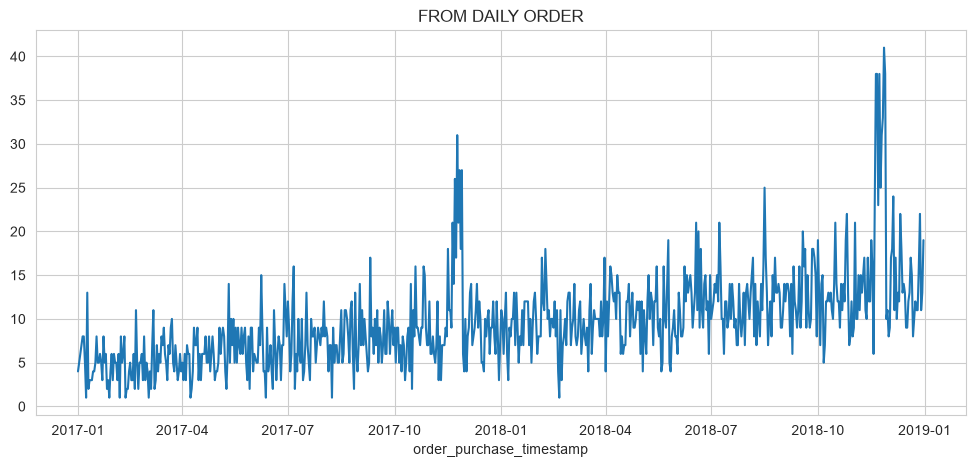

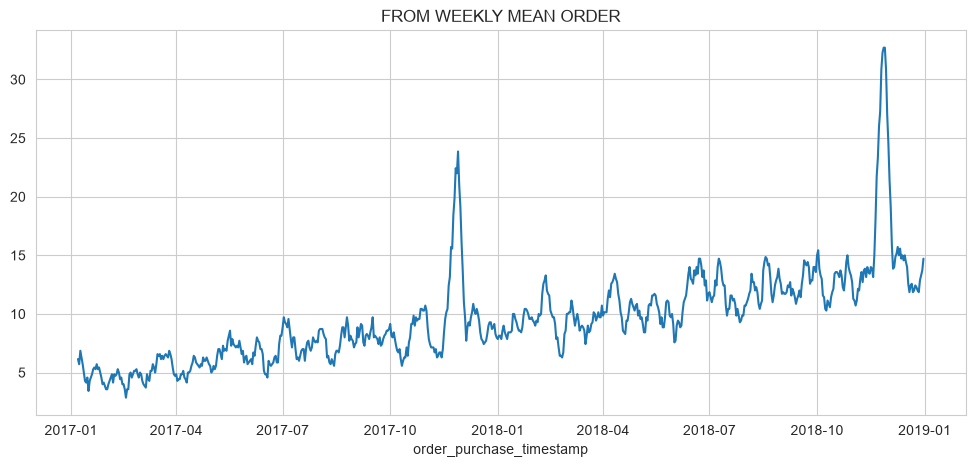

<Axes: title={'center': 'Daily Orders with 7-Days Rolling Mean'}, xlabel='order_purchase_timestamp'>

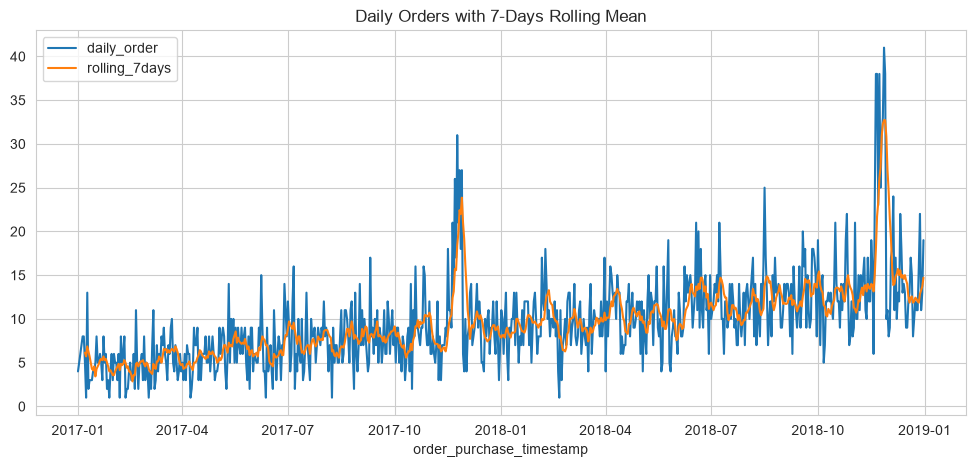

In [105]:
daily_orders_series=sales.groupby(sales["order_purchase_timestamp"].dt.date)["order_id"].nunique()
rolling_mean=daily_orders_series.rolling(window=7).mean()
daily_orders_df=daily_orders_series.to_frame(name="daily_order")
daily_orders_df["rolling_7days"]=daily_orders_df["daily_order"].rolling(window=7).mean()
### PLOTTING DATA
daily_orders_df["daily_order"].plot(figsize=(12,5),title="FROM DAILY ORDER")
plt.show()
rolling_mean.plot(figsize=(12,5),title="FROM WEEKLY MEAN ORDER")
plt.show()
daily_orders_df.plot(figsize=(12,5),title="Daily Orders with 7-Days Rolling Mean")

### Q5.4 — Day-of-week seasonality
On which day of the week do most orders happen? Use `dt.day_name()`, group, count, and plot.

<Axes: title={'center': 'WEEK VS ORDERS'}, xlabel='order_purchase_timestamp'>

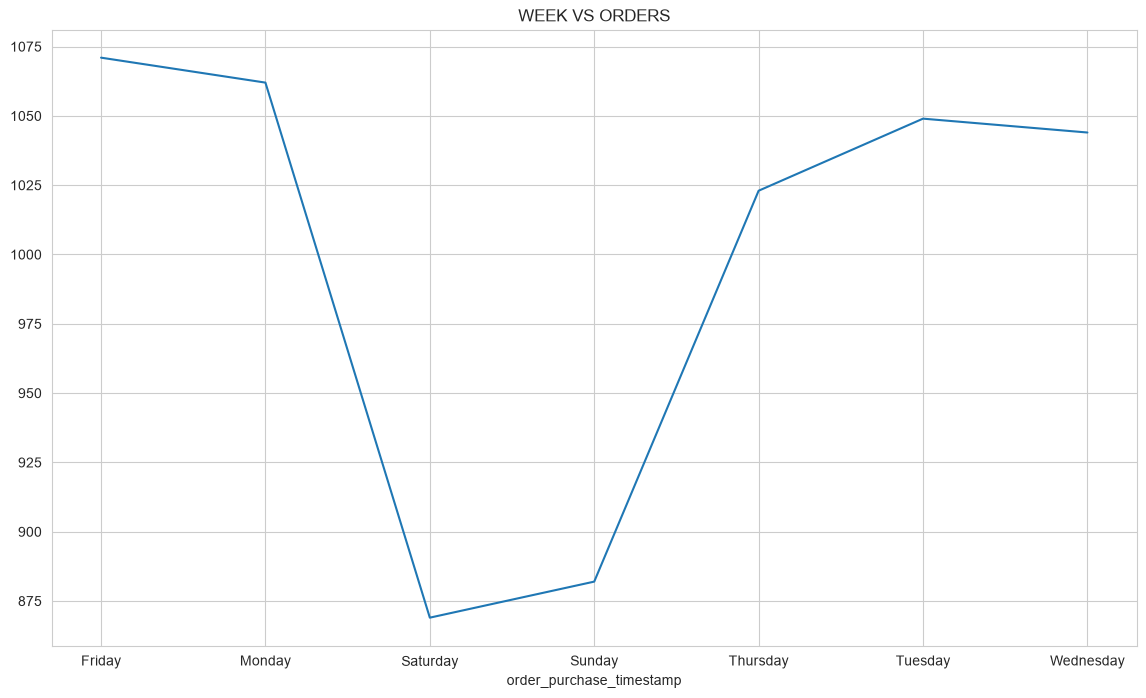

In [114]:
sales.groupby(sales["order_purchase_timestamp"].dt.day_name())["order_id"].nunique().plot(figsize=(14,8),title="WEEK VS ORDERS")

### Q5.5 — Hour-of-day seasonality
At what hour of the day do customers shop most? Bar chart of order counts by hour (0–23).

<Axes: xlabel='order_purchase_timestamp'>

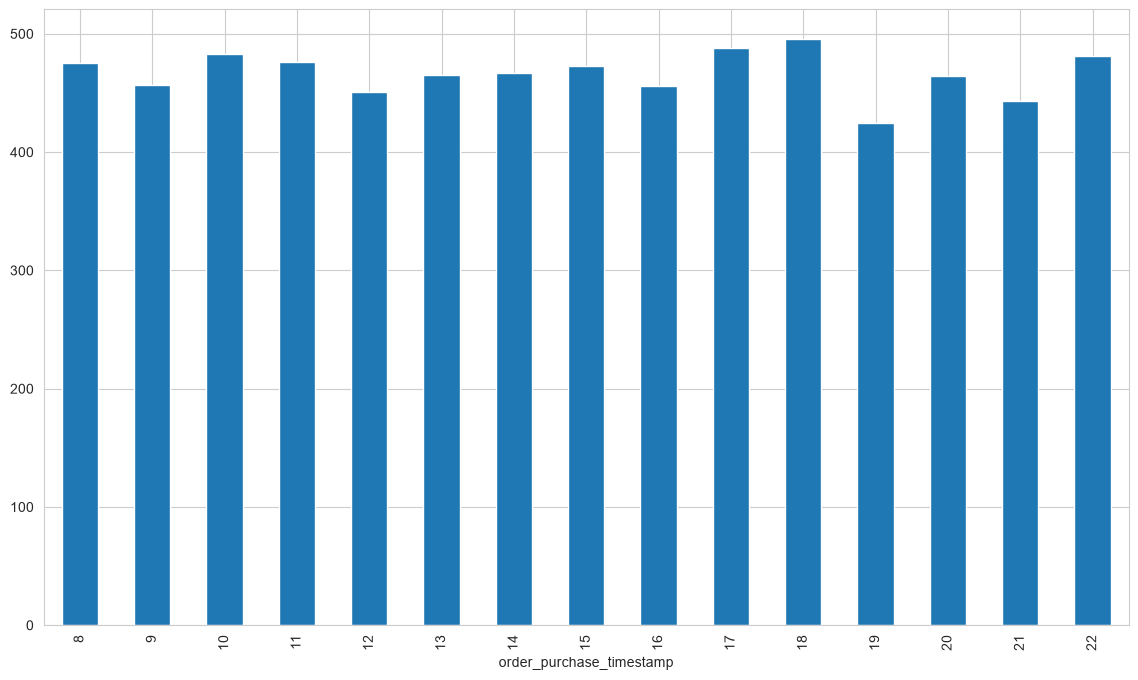

In [115]:
sales.groupby(sales["order_purchase_timestamp"].dt.hour)["order_id"].nunique().plot(figsize=(14,8),kind="bar")

### Q5.6 — Month-of-year seasonality
Aggregate across all years — for each calendar month (Jan–Dec), what is the total order count? Are there spikes (e.g. Black Friday in November)?

<Axes: title={'center': 'MONTHLY ORDER ANALYSIS'}, xlabel='order_purchase_timestamp'>

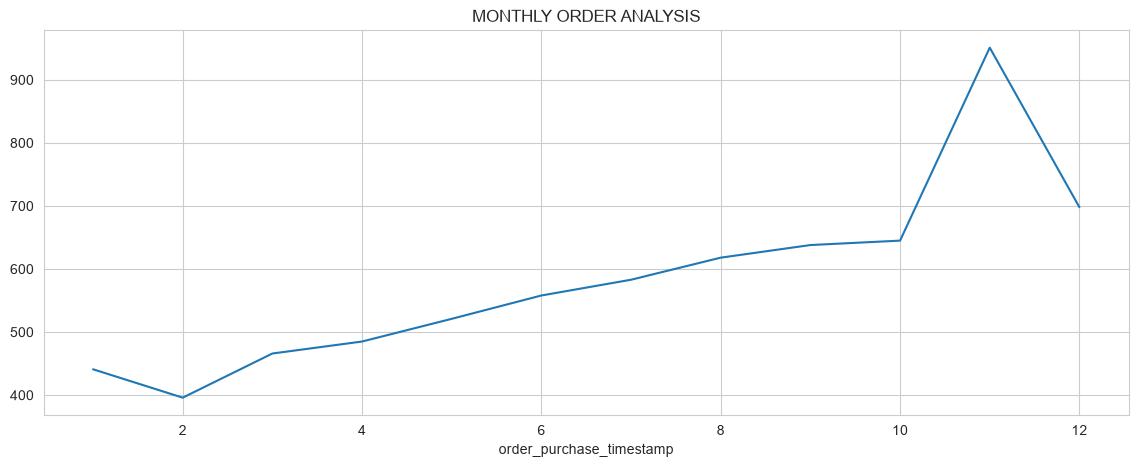

In [125]:
sales.groupby(sales["order_purchase_timestamp"].dt.month)["order_id"].nunique().plot(figsize=(14,5),title="MONTHLY ORDER ANALYSIS")

### Q5.7 — Year-over-year growth
Compare monthly revenue in 2017 to monthly revenue in 2018 for matching months. Compute YoY growth rate for each month where both years have data.

year       2017      2018  YoY_Growth_%
month                                  
1      19366.84  36656.23     89.273160
2      17151.50  31389.59     83.013672
3      19096.56  35027.00     83.420469
4      17797.30  36109.29    102.891956
5      25047.83  35551.14     41.933014
6      22601.06  41852.39     85.178881
7      29800.35  38148.38     28.013194
8      25870.24  43012.74     66.263398
9      28190.52  43979.95     56.009715
10     30229.84  47000.32     55.476575
11     44615.67  67974.54     52.355753
12     33573.22  47611.85     41.814964


<Axes: title={'center': 'REVENUE COMPARISION BETWEEN THE YEARS'}, xlabel='month'>

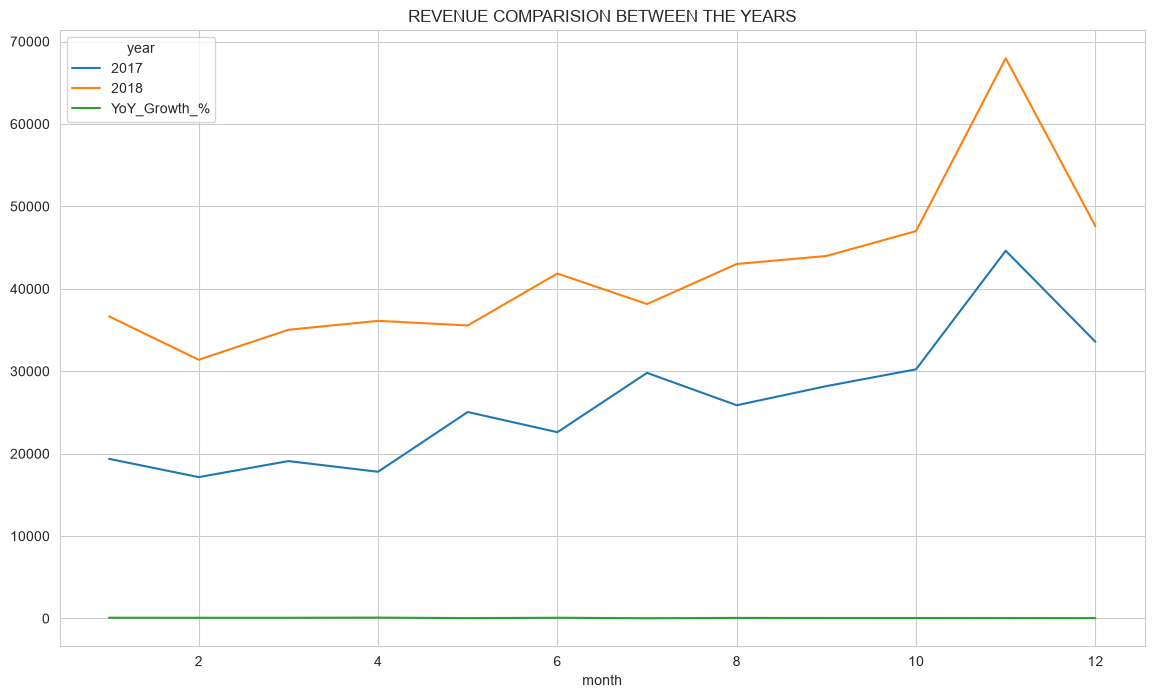

In [131]:
sales["year"] = sales["order_purchase_timestamp"].dt.year
sales["month"] = sales["order_purchase_timestamp"].dt.month
monthly_revenue=sales.groupby(["year","month"]).agg(revenue=("price","sum")).reset_index()
pvt=pd.pivot_table(data=monthly_revenue,index="month",columns="year",values="revenue")
pvt["YoY_Growth_%"]=((pvt[2018]-pvt[2017])/pvt[2017])*100
print(pvt)
pvt.plot(figsize=(14,8),title="REVENUE COMPARISION BETWEEN THE YEARS")

### Q5.8 — Delivery time analysis
For delivered orders, compute the actual delivery time in days as `order_delivered_customer_date - order_purchase_timestamp`. Then compute:
- Mean and median delivery time
- Distribution histogram
- Mean delivery time **by customer state** — top 5 slowest states

Then compute the **on-time delivery rate**: the % of orders delivered before their `order_estimated_delivery_date`.

In [155]:
delivered_df=sales[sales["order_status"]=="delivered"]
delivered_df["delivery_time"]=(delivered_df["order_delivered_customer_date"]-delivered_df["order_purchase_timestamp"])
print("MEAN DELIVERY TIME:")
print(delivered_df["delivery_time"].mean())
print("MEDIAN DELIVERY TIME:")
print(delivered_df["delivery_time"].median())
mean_by_customer_state=delivered_df.groupby("customer_state")["delivery_time"].mean()
print(mean_by_customer_state)
# mean_by_customer_state.plot(kind="bar")
delivered_df["ontime_delivery"]=np.where((delivered_df["order_estimated_delivery_date"]>delivered_df["order_delivered_customer_date"]),True,False)
on_time_delivery_rate=delivered_df["ontime_delivery"].sum()/delivered_df["ontime_delivery"].count() *100
print(f"\nON TIME DELIVERY RATE IS :{on_time_delivery_rate:.2f}%")

MEAN DELIVERY TIME:
12 days 14:00:56.399241
MEDIAN DELIVERY TIME:
12 days 15:00:00
customer_state
BA   12 days 10:47:01.052631
CE   11 days 19:42:54.301675
DF   12 days 15:57:58.991596
GO          12 days 07:51:00
MA          13 days 00:48:00
MG   12 days 12:58:47.619047
MS   11 days 23:35:47.899159
MT   12 days 12:12:59.381443
PA          12 days 12:53:00
PE   12 days 19:00:42.352941
PR   12 days 08:36:32.079207
RJ   12 days 21:04:19.427443
RS   12 days 15:25:16.800000
SC   13 days 00:09:40.263157
SP   12 days 13:24:58.043864
Name: delivery_time, dtype: timedelta64[us]

ON TIME DELIVERY RATE IS :75.55%


### Q5.9 — Time between purchase and review
For each review, compute `review_creation_date - order_purchase_timestamp` in days. Plot the distribution. Most customers leave a review how long after purchase?

0       18.0
1       18.0
2       21.0
3       21.0
4       14.0
        ... 
8588    24.0
8589    12.0
8590    12.0
8591    18.0
8592    11.0
Length: 8593, dtype: float64


<Axes: title={'center': 'Distribution of Review Delay (Days)'}, ylabel='Frequency'>

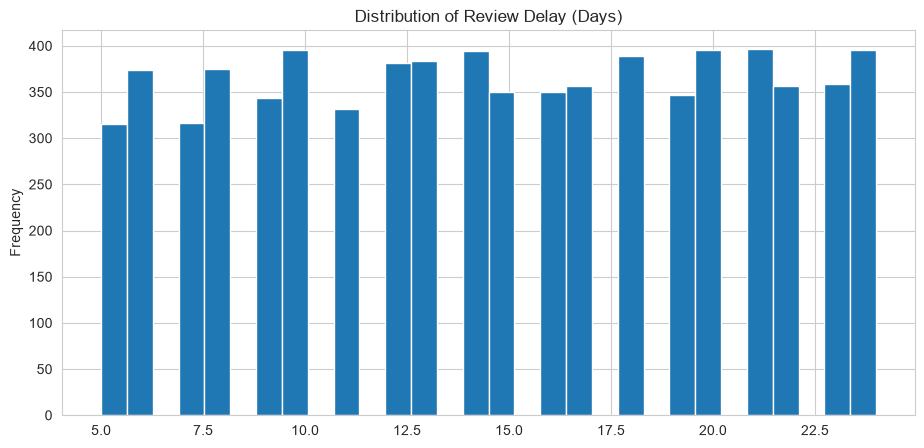

In [161]:
review_delay=(sales["review_creation_date"]-sales["order_purchase_timestamp"]).dt.days
print(review_delay)
review_delay.plot(kind="hist",bins=30,title="Distribution of Review Delay (Days)")

### Q5.10 — Cumulative revenue plot
Plot **cumulative revenue** over time (running total). This is a classic CFO chart — the steeper the curve, the more the business is growing.

<Axes: xlabel='order_purchase_timestamp'>

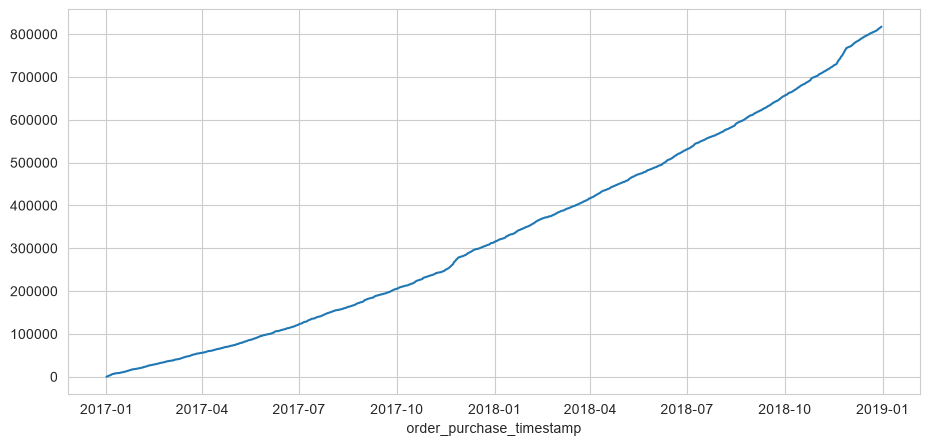

In [164]:
daily_revenue=sales.groupby(sales["order_purchase_timestamp"].dt.date)["price"].sum()
cumulative=daily_revenue.cumsum()
cumulative.plot()

---
# Part 6 — Advanced Analyses

These tie everything together. They are open-ended — emphasize *insight* and clean presentation.

### Q6.1 — Repeat customer rate
What proportion of `customer_unique_id` values appear in more than one order? Among repeat customers, what is the average number of orders?

In [183]:
n_orders=sales.groupby("customer_unique_id").agg(n_orders=("order_id","nunique"))
repeat=n_orders["n_orders"]>1
repeat_customer=repeat.sum()
total_customer=repeat.shape[0]
print(f"THE PORTION OF THE REPEATED CUSTOMER IS {(repeat_customer/total_customer):.3f}")
mean_repeated_n_order=n_orders[repeat]["n_orders"].mean()
print("AMONG REPEATED CUSTOMER, AVERAGE NO OF ORDERS IS:")
print(round(mean_repeated_n_order))

THE PORTION OF THE REPEATED CUSTOMER IS 0.850
AMONG REPEATED CUSTOMER, AVERAGE NO OF ORDERS IS:
5


### Q6.2 — RFM analysis
Compute Recency, Frequency, and Monetary values for each `customer_unique_id`:
- **Recency:** days since their most recent purchase (relative to the dataset's max date)
- **Frequency:** number of orders
- **Monetary:** total spending

Then assign each customer a 1–5 score on each dimension using `pd.qcut`. Combine into an RFM segment label like `'5-5-5'` (best customers). How many customers are in the top segment `'5-5-5'`?

In [211]:
rfm=sales.groupby("customer_unique_id").agg(
    recency_in_days=("order_purchase_timestamp",lambda x:round((x.max()-x.sort_values(ascending=False).iloc[1] if len(x)>1 else pd.Timedelta(0)).days)),
    freq=("order_id","nunique"),
    monetery=("price","sum")
).reset_index()
rfm["r_rank"]=pd.qcut(rfm["recency_in_days"].rank(method="first"),q=5,labels=[5,4,3,2,1]).astype(int)
rfm["f_rank"]=pd.qcut(rfm["freq"],q=5,labels=[1,2,3,4,5]).astype(int)
rfm["m_rank"]=pd.qcut(rfm["monetery"],q=5,labels=[1,2,3,4,5]).astype(int)
rfm["segment"]=(rfm["r_rank"].astype(str)+"-"+rfm["f_rank"].astype(str)+"-"+rfm["m_rank"].astype(str))
print(rfm)
print("TOTAL NO OF TOP SEGMENT ARE:")
print((rfm["segment"]=="5-5-5").sum())

     customer_unique_id  recency_in_days  freq  monetery  r_rank  f_rank  m_rank segment
0           uniq_000001               60     7    978.40       2       5       5   2-5-5
1           uniq_000002              129     2    246.66       2       1       2   2-1-2
2           uniq_000003               62     4    672.56       2       3       4   2-3-4
3           uniq_000004               48     2    107.94       3       1       1   3-1-1
4           uniq_000005                0     3    426.14       5       2       3   5-2-3
...                 ...              ...   ...       ...     ...     ...     ...     ...
1664        uniq_002544               68     9   1045.44       2       5       5   2-5-5
1665        uniq_002545               30     4    543.71       3       3       4   3-3-4
1666        uniq_002547               24     7    549.41       3       5       4   3-5-4
1667        uniq_002548               98     3    327.94       2       2       3   2-2-3
1668        uniq_0025

### Q6.3 — Does delivery delay hurt reviews?
Compute the relationship between delivery delay (`actual delivery date - estimated delivery date`, in days, where positive = late) and `review_score`. Group orders into "early/on-time" and "late" and compare mean review scores. Is the difference statistically significant? (Use `scipy.stats.ttest_ind`.)

In [216]:
delivery_delay=(sales["order_delivered_customer_date"]-sales["order_estimated_delivery_date"]).dt.days
early=delivery_delay<=0
sales.groupby(early)["review_score"].mean()

False    4.012739
True     4.039469
Name: review_score, dtype: float64

### Q6.4 — Category × payment method
Build a cross-tab showing the proportion of orders in each `product_category_name_english` that used `credit_card` vs. `boleto` vs. other methods. Which categories see the most installment usage?

In [221]:
sales=pd.merge(left=sales,right=payments,how="left",on="order_id")

In [229]:
payment_prop=pd.crosstab(
    sales["product_category_name_english"],
    sales["payment_type"],
    normalize="index"
)
payment_prop

payment_type,boleto,credit_card,debit_card,voucher
product_category_name_english,,,,
auto,0.202439,0.719512,0.031707,0.046341
baby,0.185039,0.732283,0.017717,0.064961
bed_bath_table,0.192000,0.746000,0.020000,0.042000
books_general_interest,0.206612,0.709366,0.017906,0.066116
computers_accessories,0.209370,0.720351,0.026354,0.043924
cool_stuff,0.169811,0.761006,0.014675,0.054507
electronics,0.182796,0.759857,0.012545,0.044803
furniture_decor,0.205882,0.722426,0.020221,0.051471
garden_tools,0.198459,0.720617,0.011561,0.069364


In [226]:
sales[sales["payment_type"]=="credit_card"].groupby("product_category_name_english").agg(
    avg_installments=("payment_installments","mean")
).sort_values("avg_installments",ascending=False).head(10)

,avg_installments
product_category_name_english,
auto,3.040678
telephony,2.965409
housewares,2.944767
baby,2.908602
cool_stuff,2.895317
bed_bath_table,2.852547
books_general_interest,2.850485
sports_leisure,2.844086
furniture_decor,2.837150


### Q6.5 — Cohort retention (advanced — optional)
Define a "cohort" as the month a customer made their first purchase. For each cohort, what proportion of those customers made another purchase 1, 2, 3, ..., 12 months later? Visualize as a heatmap.

In [231]:
sales.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name_english', 'paid', 'count_order', 'mean_review_score', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp',
       'price_vs_category_avg', 'month', 'year', 'payment_sequential', 'payment_type', 'payment_installments',
       'payment_val

cohort_index   0         1         2         3         4         5         6         7         8         9         10  \
cohort_month                                                                                                            
2017-01       1.0  0.120567  0.092199  0.120567  0.099291  0.106383  0.134752  0.177305  0.113475  0.156028  0.241135   
2017-02       1.0  0.142857  0.076190  0.152381  0.180952  0.114286  0.200000  0.180952  0.180952  0.228571  0.171429   
2017-03       1.0  0.068702  0.137405  0.099237  0.160305  0.167939  0.145038  0.122137  0.198473  0.190840  0.175573   
2017-04       1.0  0.090909  0.099174  0.181818  0.157025  0.173554  0.148760  0.198347  0.123967  0.165289  0.247934   
2017-05       1.0  0.115108  0.129496  0.165468  0.129496  0.201439  0.208633  0.151079  0.179856  0.115108  0.187050   
2017-06       1.0  0.128713  0.049505  0.089109  0.158416  0.198020  0.237624  0.108911  0.158416  0.118812  0.207921   
2017-07       1.0  0.125000  0.1

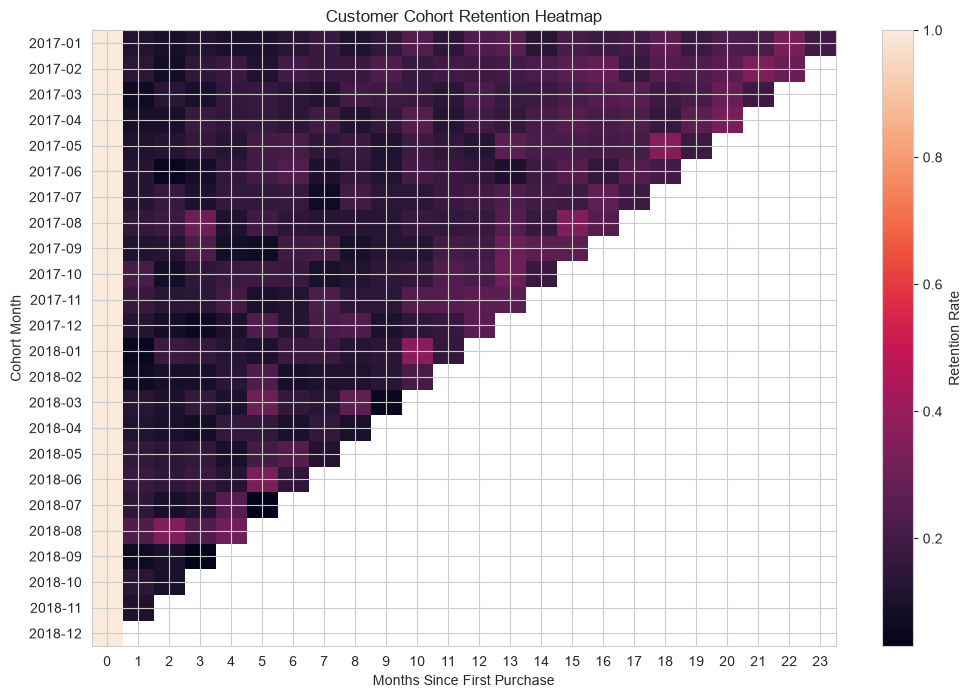

In [ ]:
cohort=sales[["customer_unique_id","order_purchase_timestamp"]].copy()
cohort["purchase_month"]=cohort["order_purchase_timestamp"].dt.to_period("M")
cohort["cohort_month"]=cohort.groupby("customer_unique_id")["purchase_month"].transform("min")
cohort["cohort_index"]=(
    (cohort["purchase_month"].dt.year - cohort["cohort_month"].dt.year) * 12
    +
    (cohort["purchase_month"].dt.month - cohort["cohort_month"].dt.month)
)
cohort_data=cohort.groupby(["cohort_month","cohort_index"]).agg(n_customers=("customer_unique_id","nunique")).reset_index()
cohort_table=pd.pivot_table(data=cohort_data,index="cohort_month",columns="cohort_index",values="n_customers")


retention=cohort_table.div(cohort_table[0],axis=0)
print(retention)


plt.figure(figsize=(12, 8))
plt.imshow(retention, aspect="auto")
plt.colorbar(label="Retention Rate")
plt.xticks(
    range(len(retention.columns)),
    retention.columns
)
plt.yticks(
    range(len(retention.index)),
    retention.index.astype(str)
)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.title("Customer Cohort Retention Heatmap")

plt.show()

---
# Part 7 — Final Business Report

Write a markdown cell below summarizing your findings. Imagine you're presenting to the executive team of an e-commerce company.

### Required sections:

1. **Executive Summary** (3–4 sentences) — overall state of the business
2. **Top 3 Insights** — with one supporting chart or statistic each
3. **Top 3 Recommendations** — concrete, data-backed actions
4. **Caveats & Limitations** — what would you want more data on?

### Grading criteria
- Insights are backed by specific numbers, not vague statements
- Each insight references a specific section/question
- Recommendations are actionable (not "improve customer service" but "extend delivery network in state X to reduce mean delivery time from N to M days")
- Writing is concise — bullet points are fine

## ✍️ Your Final Report — write below

### Executive Summary

*(write here)*

### Top 3 Insights

**1.** *(insight 1 with supporting data)*

**2.** *(insight 2 with supporting data)*

**3.** *(insight 3 with supporting data)*

### Top 3 Recommendations

**1.** *(action 1)*

**2.** *(action 2)*

**3.** *(action 3)*

### Caveats & Limitations

*(what would you investigate with more data?)*

---
## 🎓 Reflection (optional but encouraged)

Briefly answer below:
1. Which pandas concept did this assignment force you to use that you found least intuitive?
2. Which part felt most like "real" data work?
3. If you used the synthetic data option — what would you do differently with the real Olist dataset?

> **Submission:** once complete, run `Kernel → Restart and Run All` to verify every cell executes top-to-bottom without errors, then export to PDF or share the notebook directly.

---

### 📚 Further Practice
- Replace the analysis with the full Olist dataset (Kaggle) and see how your numbers change at scale.
- Add a **forecast**: use the monthly revenue series to predict the next 3 months with a simple model (e.g. linear regression on time, or `statsmodels.SARIMAX`).
- Build a **dashboard** in Streamlit or Plotly Dash from your final report.